# Week 5 – Attention Mechanism

## Implementing and Visualizing Scaled Dot-Product Attention

This notebook demonstrates Q, K, V, scaled dot-product attention, softmax weights, the final output, a heatmap, and PyTorch comparison.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
DATA=Path('../dataset')
sentences=[x.strip() for x in (DATA/'sample_sentences.txt').read_text(encoding='utf-8').splitlines() if x.strip()]
for i,s in enumerate(sentences,1): print(f'S{i}: {s}')


S1: AI learns patterns from data.
S2: Transformers use attention to connect important words in a sentence.
S3: Python is widely used for machine learning and natural language processing.
S4: A recommendation system analyzes user behavior to suggest relevant products and content.
S5: Large language models use attention mechanisms to understand relationships between tokens and generate context-aware responses.


### 1. Create Q, K and V

Five sentences of different lengths are represented as deterministic vectors for this learning example.


In [2]:
def make_embeddings(sentences,d=8):
    out=[]
    for s in sentences:
        v=np.zeros(d)
        for i,w in enumerate(s.lower().split()):
            c=sum(map(ord,w)); v[i%d]+=(c%97)/97; v[(i*3+1)%d]+=len(w)/15
        n=np.linalg.norm(v); out.append(v/n if n else v)
    return np.array(out)
X=make_embeddings(sentences); Q,K,V=X,X,X
print('Q shape:',Q.shape); print('K shape:',K.shape); print('V shape:',V.shape)


Q shape: (5, 8)
K shape: (5, 8)
V shape: (5, 8)


### 2. Scaled Dot-Product Attention

Formula: `Attention(Q,K,V) = softmax((QKᵀ) / √dₖ)V`


In [3]:
def softmax(x):
    x=x-np.max(x,axis=-1,keepdims=True); e=np.exp(x); return e/e.sum(axis=-1,keepdims=True)
scores=(Q@K.T)/np.sqrt(Q.shape[1]); weights=softmax(scores); output=weights@V
print('Attention scores:\n',scores); print('\nAttention weights:\n',weights); print('\nAttention output:\n',output)


Attention scores:
 [[0.35355339 0.30429053 0.25774738 0.30062341 0.26374208]
 [0.30429053 0.35355339 0.31537804 0.30125758 0.31874708]
 [0.25774738 0.31537804 0.35355339 0.32588153 0.32191905]
 [0.30062341 0.30125758 0.32588153 0.35355339 0.31064446]
 [0.26374208 0.31874708 0.32191905 0.31064446 0.35355339]]

Attention weights:
 [[0.2117244  0.20154699 0.19238131 0.20080925 0.19353805]
 [0.19711507 0.20706868 0.19931275 0.19651813 0.19998537]
 [0.18879845 0.19999867 0.2077813  0.20211043 0.20131115]
 [0.1964389  0.19656351 0.20146377 0.2071165  0.19841732]
 [0.19017061 0.20092398 0.20156232 0.19930255 0.20804054]]

Attention output:
 [[0.35088817 0.43025578 0.30800319 0.27353118 0.45430847 0.26862586
  0.20216397 0.29148018]
 [0.35758866 0.43084082 0.30806177 0.27215063 0.44888811 0.27034062
  0.20660528 0.28994432]
 [0.3614797  0.42872118 0.31245424 0.27227729 0.44489275 0.27040384
  0.20787068 0.29016872]
 [0.35737614 0.42785289 0.31281608 0.27324488 0.44822446 0.26981635
  0.2054029

### 3. Attention Heatmap


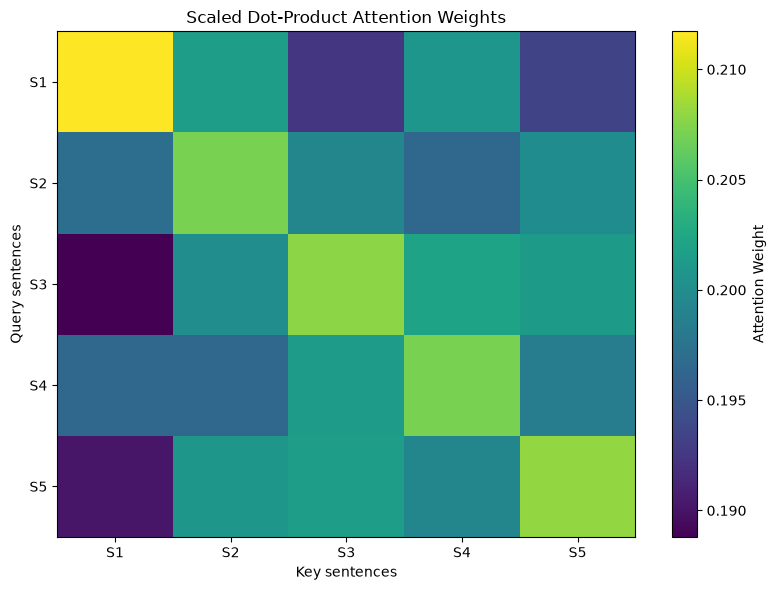

In [4]:
plt.figure(figsize=(8,6)); plt.imshow(weights,aspect='auto'); plt.colorbar(label='Attention Weight')
plt.xticks(range(5),[f'S{i}' for i in range(1,6)]); plt.yticks(range(5),[f'S{i}' for i in range(1,6)])
plt.xlabel('Key sentences'); plt.ylabel('Query sentences'); plt.title('Scaled Dot-Product Attention Weights'); plt.tight_layout(); plt.show()


### 4. Save Required Outputs


In [5]:
pd.DataFrame(weights,index=[f'Sentence_{i}' for i in range(1,6)],columns=[f'Sentence_{i}' for i in range(1,6)]).to_csv(DATA/'attention_weights.csv')
pd.DataFrame(output,index=[f'Sentence_{i}' for i in range(1,6)],columns=[f'dim_{i}' for i in range(1,9)]).to_csv(DATA/'attention_output.csv')
plt.figure(figsize=(8,6)); plt.imshow(weights,aspect='auto'); plt.colorbar(label='Attention Weight'); plt.tight_layout(); plt.savefig(DATA/'attention_heatmap.png',dpi=150); plt.close()
print('Saved attention_weights.csv, attention_output.csv and attention_heatmap.png')


Saved attention_weights.csv, attention_output.csv and attention_heatmap.png


### 5. Compare Manual NumPy Attention with PyTorch


In [6]:
tq=torch.tensor(Q,dtype=torch.float32); tk=torch.tensor(K,dtype=torch.float32); tv=torch.tensor(V,dtype=torch.float32)
tw=torch.softmax((tq@tk.T)/np.sqrt(Q.shape[1]),dim=-1); tout=tw@tv
diff=np.max(np.abs(output-tout.numpy())); print('Maximum difference:',f'{diff:.8f}')


Maximum difference: 0.00000004


## Observations

- Attention scores measure relationships between Q and K.
- Softmax converts scores into normalized attention weights.
- The output is a weighted combination of V.
- The heatmap visualizes how attention is distributed.
- NumPy and PyTorch implementations should produce nearly identical results.
